# Tugas Mandiri — Pertemuan 4: Deployment Model
## Segmentasi Nasabah Kartu Kredit dengan K-Means Clustering

---

| | |
|---|---|
| **NPM** | 51423096 |
| **Nama Lengkap** | Nazril Bintang Pratama |
| **Kelas Kursus** | Kelas F |
| **Mata Kuliah** | Data Science — Kursus Data Science (Skema Supervisor Ilmuwan Data) |
| **Topik** | Unsupervised Learning — Clustering & Deployment |
| **Metodologi** | CRISP-DM (Cross-Industry Standard Process for Data Mining) |

---

Notebook ini berisi seluruh proses **CRISP-DM** mulai dari *Business Understanding* sampai
*Evaluation*, serta disertai *Deployment* model dalam bentuk aplikasi **Streamlit**.

**Struktur CRISP-DM:**

| Fase | Bagian |
|---|---|
| 1. Business Understanding | Tujuan bisnis & perumusan masalah |
| 2. Data Understanding | Eksplorasi struktur, kualitas, dan karakteristik data |
| 3. Data Preparation | Pembersihan, pemilihan fitur, standarisasi |
| 4. Modeling | K-Means, Elbow Method, Silhouette Score, PCA |
| 5. Evaluation | Silhouette Score, Davies-Bouldin Index, profil cluster |
| 6. Deployment | Aplikasi Streamlit (segmentasi nasabah baru) |

## Sumber Data

**Nama Dataset:** Credit Card Dataset for Clustering

**Sumber:** Kaggle — *Credit Card Dataset for Clustering*
- URL: <https://www.kaggle.com/datasets/arjunbhasin2013/ccdata>
- Kontributor: Arjun Bhasin
- Berkas utama: `CC GENERAL.csv`

**Deskripsi dataset (kutipan sumber):**

> *"This case requires trainees to develop a customer segmentation to define marketing
> strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit
> card holders during the last 6 months. The file is at a customer level with 18
> behavioral variables."*

**Lisensi & akses:** Dataset tersedia publik di Kaggle untuk keperluan pembelajaran
(*Attribution* / CC BY). Berkas yang disertakan pada folder pengumpulan ini
(`CC_GENERAL.csv`) merupakan salinan dari sumber tersebut.

### Pemenuhan Kriteria Dataset

| Kriteria | Syarat | Dataset ini | Status |
|---|---|---|---|
| Bentuk data | Tabular | CSV, tabel baris × kolom | ✅ |
| Jumlah baris | ≥ 1000 | **8.950 baris** | ✅ |
| Jumlah kolom | ≥ 8 | **18 kolom** | ✅ |
| Fitur numerik | ≥ 3 | **17 kolom numerik** | ✅ |
| Fitur untuk training | 3 fitur numerik | `BALANCE`, `PURCHASES`, `CREDIT_LIMIT` | ✅ |
| Sumber data | Dicatat | Kaggle — `arjunbhasin2013/ccdata` | ✅ |

## Mengapa Dataset Ini Dapat Digunakan untuk Clustering?

Clustering adalah teknik **Unsupervised Learning** yang mengelompokkan data berdasarkan
kemiripan karakteristik, **tanpa memerlukan label kelas**. Dataset ini memenuhi syarat
untuk clustering karena alasan-alasan berikut.

### 1. Tidak Memiliki Variabel Target (Unlabeled)
Dataset ini **tidak memiliki kolom label** yang perlu diprediksi. Seluruh 18 kolom berisi
karakteristik dan perilaku nasabah. Ini adalah kondisi ideal untuk Unsupervised Learning —
tidak ada *ground truth* yang harus dipelajari, sehingga tugasnya murni menemukan struktur
tersembunyi di dalam data.

### 2. Berisi Karakteristik Perilaku yang Bersifat Kontinu dan Terukur
Kolom-kolom seperti `BALANCE` (saldo), `PURCHASES` (total pembelian), `CREDIT_LIMIT`
(limit kredit), `CASH_ADVANCE` (penarikan tunai), dan `TENURE` (lama menjadi nasabah)
merupakan **variabel numerik kontinu** yang mengukur intensitas perilaku. Ukuran jarak
(*Euclidean distance*) yang menjadi dasar K-Means menjadi bermakna ketika diterapkan pada
variabel numerik seperti ini.

### 3. Memiliki Variasi (Heterogenitas) yang Tinggi
Tujuan clustering adalah memisahkan kelompok yang berbeda. Dataset ini memiliki variasi
yang sangat besar antar nasabah — misalnya kolom `PURCHASES` memiliki nilai minimum 0
hingga nilai maksimum ribuan. Perbedaan karakteristik yang lebar inilah yang memungkinkan
terbentuknya **cluster yang bermakna dan dapat dibedakan**, bukan cluster yang saling
tumpang tindih.

### 4. Ukuran Data Memadai
Dengan **8.950 observasi**, jumlah data cukup banyak sehingga hasil clustering **stabil
dan representatif**. Algoritma seperti K-Means membutuhkan jumlah data yang memadai agar
posisi *centroid* tidak sekadar mencerminkan noise pada data yang sedikit.

### 5. Memiliki Konteks Bisnis yang Jelas
Setiap cluster yang terbentuk dapat **langsung diterjemahkan menjadi segmen bisnis** yang
bermakna (misalnya: nasabah *high spender*, nasabah pengguna *cash advance*, nasabah
pasif). Ini penting karena hasil clustering hanya berguna apabila dapat diinterpretasikan
dan ditindaklanjuti secara bisnis — sesuai dengan semangat CRISP-DM.

### 6. Membutuhkan Segmentasi, Bukan Prediksi
Permasalahan pada dataset ini adalah *"kelompok nasabah seperti apa yang ada di dalam
data?"* — bukan *"apakah nasabah X akan berhenti?"*. Pertanyaan seperti ini hanya dapat
dijawab dengan pendekatan clustering, sehingga pemilihan metode menjadi tepat sasaran.

---
# Fase 1 — Business Understanding

## 1.1 Latar Belakang

Industri kartu kredit memiliki karakteristik unik: pendapatan utama perusahaan berasal dari
**bunga pinjaman, biaya transaksi, dan denda keterlambatan**. Namun tidak semua nasabah
memberikan kontribusi yang sama. Sebagian nasabah membelanjakan dana dalam jumlah besar
dan membayar penuh setiap bulan, sebagian lain lebih sering menggunakan fasilitas
penarikan tunai (*cash advance*) yang berbunga tinggi, dan sebagian lagi memiliki kartu
tetapi hampir tidak pernah menggunakannya.

Tim pemasaran perusahaan menghadapi tantangan: **bagaimana menyesuaikan strategi pemasaran
untuk ribuan nasabah tanpa harus menganalisis satu per satu?** Menganalisis nasabah secara
individual tidak mungkin dilakukan dan tidak efisien.

## 1.2 Perumusan Masalah

Tanpa pemahaman mengenai kelompok nasabah, perusahaan berisiko:
- Membuang anggaran pemasaran untuk nasabah yang memang tidak aktif bertransaksi.
- Menawarkan produk yang tidak relevan kepada segmen yang salah.
- Kehilangan nasabah bernilai tinggi (*high-value customer*) karena tidak mengenali mereka.
- Tidak mampu menyusun strategi retensi yang tepat sasaran.

## 1.3 Tujuan Bisnis

1. **Mengidentifikasi segmen nasabah** berdasarkan perilaku penggunaan kartu kredit.
2. **Memahami karakteristik setiap segmen** agar dapat dirumuskan strategi pemasaran
   yang berbeda untuk tiap segmen.
3. **Menyediakan alat bantu (*tool*) interaktif** yang dapat digunakan tim pemasaran untuk
   menentukan segmen seorang nasabah baru secara langsung.

## 1.4 Tujuan Analisis (Data Mining)

1. Melakukan segmentasi nasabah kartu kredit menggunakan algoritma **K-Means Clustering**.
2. Menentukan jumlah cluster optimal menggunakan **Elbow Method** dan **Silhouette Score**.
3. Mengevaluasi kualitas cluster menggunakan **Silhouette Score** dan
   **Davies-Bouldin Index**.
4. Menginterpretasikan profil setiap cluster ke dalam bahasa bisnis.
5. Mendeploy model ke dalam aplikasi **Streamlit** agar dapat digunakan secara interaktif.

## 1.5 Kriteria Keberhasilan

| Aspek | Kriteria |
|---|---|
| Teknis | Model menghasilkan cluster dengan Silhouette Score > 0,2 dan struktur yang dapat dibedakan |
| Bisnis | Setiap cluster dapat dijelaskan dalam bahasa bisnis dan menghasilkan rekomendasi tindakan yang berbeda |
| Deployment | Aplikasi Streamlit berjalan dan mampu memprediksi segmen nasabah baru |

---
# Fase 2 — Data Understanding

Tahap ini bertujuan memahami struktur, kualitas, dan karakteristik data sebelum melakukan
pemodelan. Kualitas hasil clustering sangat bergantung pada seberapa baik data dipahami.

In [1]:
# Import library yang diperlukan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

# Pengaturan tampilan
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Library berhasil diimpor.")
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)

Library berhasil diimpor.
NumPy      : 2.4.6
Pandas     : 3.0.3


In [2]:
# Memuat dataset

df = pd.read_csv("CC_GENERAL.csv")
print("Dataset berhasil dimuat.")
df.head()

Dataset berhasil dimuat.


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### 2.1 Ukuran Dataset

Mari periksa jumlah baris dan kolom untuk memastikan dataset memenuhi kriteria tugas.

In [3]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 8950
Jumlah kolom : 18


### 2.2 Struktur dan Tipe Data

Selanjutnya diperiksa tipe data setiap kolom serta jumlah nilai yang terisi. Tahap ini
penting untuk mengidentifikasi kolom mana yang bersifat numerik dan mana yang kategorikal,
serta mendeteksi keberadaan *missing value*.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

### 2.3 Statistik Deskriptif

Statistik deskriptif memberikan gambaran awal mengenai sebaran nilai pada setiap variabel
numerik: nilai rata-rata, simpangan baku, serta nilai minimum dan maksimum.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


### 2.4 Pemeriksaan Kualitas Data: Missing Value dan Data Duplikat

Sebelum pemodelan, kualitas data harus dipastikan. Missing value dapat menyebabkan error
pada perhitungan jarak, sedangkan data duplikat dapat membuat suatu pola menjadi terlalu
dominan sehingga bias.

In [6]:
# Memeriksa missing value
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Jumlah kolom yang memiliki missing value:", len(missing))
print()
print(missing.to_string() if len(missing) else "Tidak ada missing value.")

print()
print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah kolom yang memiliki missing value: 2

MINIMUM_PAYMENTS    313
CREDIT_LIMIT          1

Jumlah data duplikat : 0


### 2.5 Exploratory Data Analysis (EDA)

#### 2.5.1 Distribusi Tiga Fitur Utama

Ketiga fitur yang akan digunakan untuk clustering — `BALANCE`, `PURCHASES`, dan
`CREDIT_LIMIT` — divisualisasikan untuk memahami sebarannya.

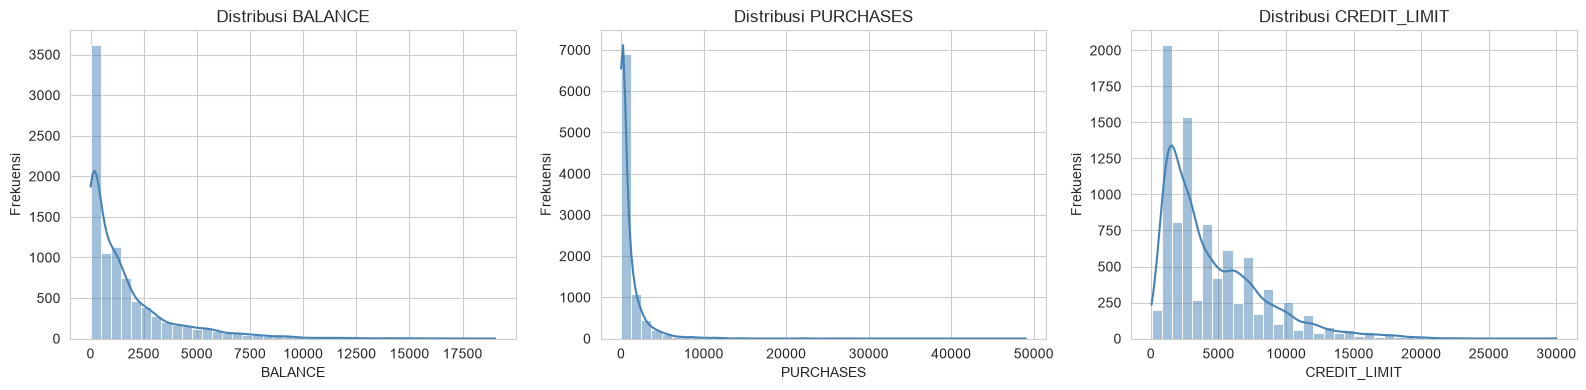

In [7]:
FITUR = ["BALANCE", "PURCHASES", "CREDIT_LIMIT"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, kolom in zip(axes, FITUR):
    sns.histplot(df[kolom], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {kolom}")
    ax.set_xlabel(kolom)
    ax.set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Berdasarkan histogram di atas, dapat dilihat bahwa:

- **`BALANCE`** memiliki sebaran *right-skewed* (menceng ke kanan). Sebagian besar nasabah
  memiliki saldo rendah hingga menengah, namun terdapat sejumlah kecil nasabah dengan saldo
  sangat tinggi.
- **`PURCHASES`** menunjukkan pola yang paling ekstrem: mayoritas nasabah memiliki total
  pembelian rendah (mendekati 0), sementara segelintir nasabah memiliki nilai pembelian
  yang sangat besar. Ini menandakan adanya **ketimpangan perilaku belanja** yang tajam.
- **`CREDIT_LIMIT`** relatif lebih menyebar, dengan konsentrasi pada rentang menengah dan
  beberapa nilai ekstrem di sisi kanan.

Adanya *skewness* tinggi ini merupakan hal yang wajar pada data keuangan, dan justru
menguatkan alasan penggunaan clustering: data yang menumpuk di satu sisi namun memiliki
"ekor panjang" biasanya menyembunyikan kelompok-kelompok yang berbeda di dalamnya.

#### 2.5.2 Pemeriksaan Outlier

*Outlier* (nilai ekstrem) perlu diidentifikasi karena dapat memengaruhi posisi *centroid*
pada K-Means. Boxplot digunakan untuk melihat keberadaannya.

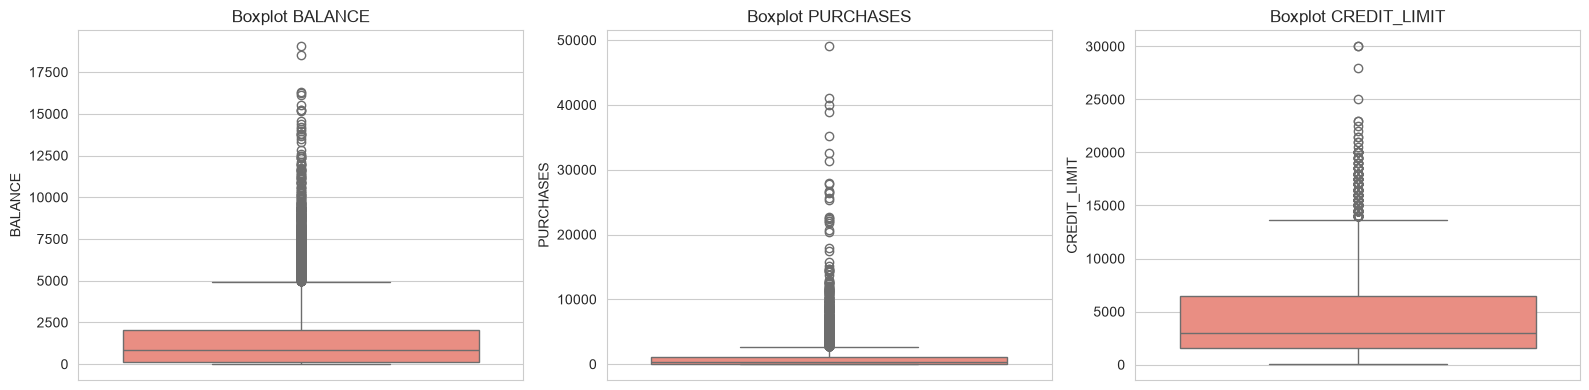

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, kolom in zip(axes, FITUR):
    sns.boxplot(y=df[kolom], ax=ax, color="salmon")
    ax.set_title(f"Boxplot {kolom}")
    ax.set_ylabel(kolom)

plt.tight_layout()
plt.show()

In [9]:
# Ringkasan sebaran dan deteksi outlier dengan metode IQR

ringkasan = []

for kolom in FITUR:
    q1 = df[kolom].quantile(0.25)
    q3 = df[kolom].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    jumlah_outlier = ((df[kolom] < batas_bawah) | (df[kolom] > batas_atas)).sum()

    ringkasan.append({
        "Fitur": kolom,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Batas Atas": round(batas_atas, 2),
        "Jumlah Outlier": jumlah_outlier,
        "Persentase (%)": round(jumlah_outlier / len(df) * 100, 2),
    })

pd.DataFrame(ringkasan)

,Fitur,Q1,Q3,IQR,Batas Atas,Jumlah Outlier,Persentase (%)
0,BALANCE,128.28,2054.14,1925.86,4942.93,695,7.77
1,PURCHASES,39.64,1110.13,1070.50,2715.87,808,9.03
2,CREDIT_LIMIT,1600.00,6500.00,4900.00,13850.00,248,2.77


Ketiga fitur memiliki outlier dengan proporsi yang cukup besar, terutama pada `PURCHASES`.
Hal ini konsisten dengan histogram yang sebelumnya menunjukkan sebaran *right-skewed*.

**Keputusan penanganan outlier:** pada tahap *Data Preparation*, outlier **tidak dihapus**,
melainkan dibiarkan. Alasannya, dalam konteks segmentasi nasabah, nasabah dengan
pengeluaran sangat besar **justru merupakan segmen yang paling penting secara bisnis**
(*high-value customer*). Menghapus mereka akan menghilangkan informasi paling bernilai.
Yang dilakukan adalah **standarisasi** agar perbedaan skala antar fitur tidak mendominasi
perhitungan jarak.

#### 2.5.3 Korelasi Antar Fitur

Pemeriksaan korelasi berguna untuk mengetahui hubungan antar fitur dan mendeteksi
multikolinearitas.

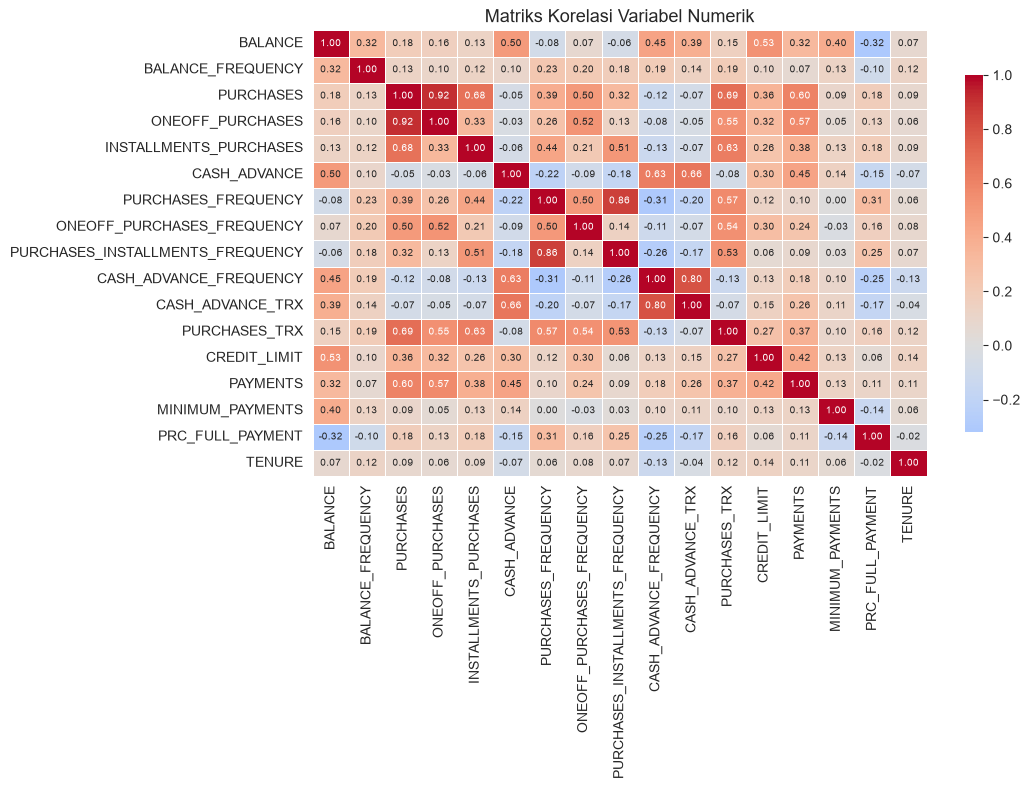

In [10]:
plt.figure(figsize=(11, 8))

kolom_numerik = df.select_dtypes(include=np.number).columns
matriks_korelasi = df[kolom_numerik].corr()

sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)

plt.title("Matriks Korelasi Variabel Numerik", fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Temuan Utama Tahap Data Understanding

Berdasarkan seluruh pemeriksaan di atas, diperoleh kesimpulan berikut:

1. **Ukuran data memadai** — 8.950 baris dan 18 kolom, melebihi syarat minimum tugas.
2. **Data didominasi variabel numerik** — 17 dari 18 kolom bertipe numerik. Hanya
   `CUST_ID` yang berupa teks, dan kolom ini hanya berfungsi sebagai identitas sehingga
   tidak digunakan dalam pemodelan.
3. **Terdapat missing value** pada `MINIMUM_PAYMENTS` (313 baris) dan `CREDIT_LIMIT`
   (1 baris). Keduanya perlu ditangani pada tahap *Data Preparation*.
4. **Tidak terdapat data duplikat** — kualitas data tergolong baik.
5. **Sebaran data sangat tidak normal (*skewed*)** dan mengandung banyak outlier. Hal ini
   wajar untuk data keuangan dan menegaskan pentingnya **standarisasi** sebelum clustering.

---
# Fase 3 — Data Preparation

Tahap ini menyiapkan data mentah menjadi bentuk yang siap digunakan untuk pemodelan.
Tahapan meliputi: penanganan *missing value*, pemilihan fitur, dan standarisasi.

### 3.1 Penanganan Missing Value

Terdapat dua kolom dengan missing value:
- `MINIMUM_PAYMENTS` — 313 nilai kosong
- `CREDIT_LIMIT` — 1 nilai kosong

**Strategi penanganan:**

- `MINIMUM_PAYMENTS` **tidak digunakan** sebagai fitur clustering, sehingga missing value
  pada kolom ini tidak memengaruhi model. Kolom ini tetap dibiarkan apa adanya untuk
  keperluan eksplorasi.
- `CREDIT_LIMIT` **digunakan** sebagai fitur clustering, sehingga missing value **harus**
  ditangani. Karena hanya terdapat 1 baris yang kosong, baris tersebut **dihapus**. Dengan
  menghapus 1 dari 8.950 baris (0,011%), informasi yang hilang dapat diabaikan.

**Catatan:** untuk `MINIMUM_PAYMENTS` yang akan disimpan sebagai bagian dari dataset hasil
cluster, nilai kosong diisi dengan **median**. Median dipilih karena lebih tahan terhadap
*outlier* dibandingkan rata-rata.

In [11]:
# Menyalin data agar data asli tetap terjaga
data = df.copy()

# Mengisi missing value MINIMUM_PAYMENTS dengan median (untuk keperluan profil cluster)
median_min_pay = data["MINIMUM_PAYMENTS"].median()
data["MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].fillna(median_min_pay)
print(f"MINIMUM_PAYMENTS diisi dengan median: {median_min_pay:.2f}")

# Menghapus baris dengan CREDIT_LIMIT kosong (hanya 1 baris)
sebelum = len(data)
data = data.dropna(subset=["CREDIT_LIMIT"]).reset_index(drop=True)
sesudah = len(data)

print(f"Baris dihapus karena CREDIT_LIMIT kosong: {sebelum - sesudah}")
print(f"Jumlah baris sekarang: {sesudah}")
print()
print("Sisa missing value:", data.isnull().sum().sum())

MINIMUM_PAYMENTS diisi dengan median: 312.34
Baris dihapus karena CREDIT_LIMIT kosong: 1
Jumlah baris sekarang: 8949

Sisa missing value: 0


### 3.2 Pemilihan Fitur untuk Clustering

Sesuai ketentuan tugas, digunakan **3 fitur numerik** untuk proses training. Ketiga fitur
dipilih karena mewakili tiga dimensi utama hubungan nasabah dengan perusahaan:

| Fitur | Deskripsi | Alasan Pemilihan |
|---|---|---|
| `BALANCE` | Saldo yang tersisa di rekening untuk melakukan pembelian | Menggambarkan **kapasitas finansial** nasabah |
| `PURCHASES` | Total jumlah pembelian yang dilakukan melalui rekening | Menggambarkan **intensitas belanja** nasabah |
| `CREDIT_LIMIT` | Batas kredit yang diberikan kepada nasabah | Menggambarkan **tingkat kepercayaan** perusahaan terhadap nasabah |

Ketiga fitur ini saling melengkapi: seorang nasabah dapat memiliki limit kredit tinggi
tetapi jarang berbelanja, atau sebaliknya. Kombinasi ketiganya memungkinkan terbentuknya
segmentasi yang bermakna.

In [12]:
# Menentukan fitur untuk clustering (3 fitur numerik)
fitur = ["BALANCE", "PURCHASES", "CREDIT_LIMIT"]

X = data[fitur].copy()

print("Fitur yang digunakan :", fitur)
print("Shape data fitur     :", X.shape)
print()
X.head()

Fitur yang digunakan : ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
Shape data fitur     : (8949, 3)



,BALANCE,PURCHASES,CREDIT_LIMIT
0,40.900749,95.40,1000.0
1,3202.467416,0.00,7000.0
2,2495.148862,773.17,7500.0
3,1666.670542,1499.00,7500.0
4,817.714335,16.00,1200.0


### 3.3 Standarisasi Data

**Mengapa standarisasi diperlukan?**

K-Means menghitung kedekatan data menggunakan **jarak Euclidean**. Jika antar fitur
terdapat perbedaan skala yang besar, fitur dengan rentang nilai lebih besar akan
**mendominasi** perhitungan jarak dan membuat fitur lain nyaris tidak berpengaruh.

Sebagai ilustrasi, `PURCHASES` memiliki rentang nilai dari 0 hingga lebih dari 49.000,
sementara `BALANCE` memiliki rentang 0 hingga sekitar 19.000. Tanpa standarisasi,
`PURCHASES` akan mendominasi penentuan cluster.

**StandardScaler** mentransformasi setiap fitur sehingga memiliki **rata-rata 0** dan
**simpangan baku 1**, dengan rumus:

$$z = \frac{x - \mu}{\sigma}$$

Dengan demikian, ketiga fitur berada pada skala yang setara dan berkontribusi secara
seimbang terhadap perhitungan jarak.

In [13]:
# Standarisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standarisasi selesai.")
print("Shape data setelah standarisasi:", X_scaled.shape)
print()
print("Verifikasi (harus mendekati 0 dan 1):")
print("  Rata-rata :", np.round(X_scaled.mean(axis=0), 6))
print("  Std dev   :", np.round(X_scaled.std(axis=0), 6))

Standarisasi selesai.
Shape data setelah standarisasi: (8949, 3)

Verifikasi (harus mendekati 0 dan 1):
  Rata-rata : [0. 0. 0.]
  Std dev   : [1. 1. 1.]


In [14]:
# Menampilkan data sebelum dan sesudah standarisasi
X_scaled_df = pd.DataFrame(X_scaled, columns=fitur)

print("=== 5 data teratas SEBELUM standarisasi ===")
print(X.head().to_string())
print()
print("=== 5 data teratas SESUDAH standarisasi ===")
print(X_scaled_df.head().to_string())

=== 5 data teratas SEBELUM standarisasi ===
       BALANCE  PURCHASES  CREDIT_LIMIT
0    40.900749      95.40        1000.0
1  3202.467416       0.00        7000.0
2  2495.148862     773.17        7500.0
3  1666.670542    1499.00        7500.0
4   817.714335      16.00        1200.0

=== 5 data teratas SESUDAH standarisasi ===
    BALANCE  PURCHASES  CREDIT_LIMIT
0 -0.732054  -0.424934     -0.960380
1  0.786858  -0.469584      0.688601
2  0.447041  -0.107716      0.826016
3  0.049015   0.231995      0.826016
4 -0.358849  -0.462095     -0.905414


### 3.4 Ringkasan Tahap Data Preparation

| Tahapan | Tindakan | Hasil |
|---|---|---|
| Penanganan missing value | `MINIMUM_PAYMENTS` diisi median; 1 baris `CREDIT_LIMIT` kosong dihapus | 0 missing value |
| Pemilihan fitur | Dipilih 3 fitur numerik: `BALANCE`, `PURCHASES`, `CREDIT_LIMIT` | Matriks 8.949 × 3 |
| Standarisasi | `StandardScaler` (mean = 0, std = 1) | Skala antar fitur setara |

Data kini siap masuk ke tahap pemodelan.

---
# Fase 4 — Modeling

Pada tahap ini dilakukan pembentukan cluster menggunakan algoritma **K-Means**. Karena
K-Means memerlukan jumlah cluster (*k*) yang ditentukan terlebih dahulu, jumlah cluster
optimal dicari menggunakan **Elbow Method** dan diperkuat dengan **Silhouette Score**.

### 4.1 Elbow Method

**Elbow Method** bekerja dengan menghitung **inertia** (Within-Cluster Sum of Squares)
untuk setiap nilai *k*. Inertia mengukur seberapa jauh data dari *centroid* clusternya —
semakin kecil nilainya, semakin rapat cluster yang terbentuk.

Namun, inertia **selalu menurun** seiring bertambahnya *k* (pada *k* = jumlah data,
inertia = 0). Karena itu, yang dicari bukan nilai terkecil, melainkan **titik "siku"
(*elbow*)** — titik di mana penambahan cluster berikutnya tidak lagi memberikan penurunan
inertia yang signifikan.

In [15]:
# Menghitung inertia untuk k = 2 sampai 11
inertia = []
rentang_k = range(2, 12)

for k in rentang_k:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Menampilkan nilai inertia
hasil_inertia = pd.DataFrame({
    "Jumlah Cluster (k)": list(rentang_k),
    "Inertia": np.round(inertia, 2),
})
hasil_inertia

,Jumlah Cluster (k),Inertia
0,2,17024.47
1,3,13214.46
2,4,10237.13
3,5,8533.55
4,6,7125.23
5,7,6327.36
6,8,5663.13
7,9,5082.37
8,10,4690.03
9,11,4422.34


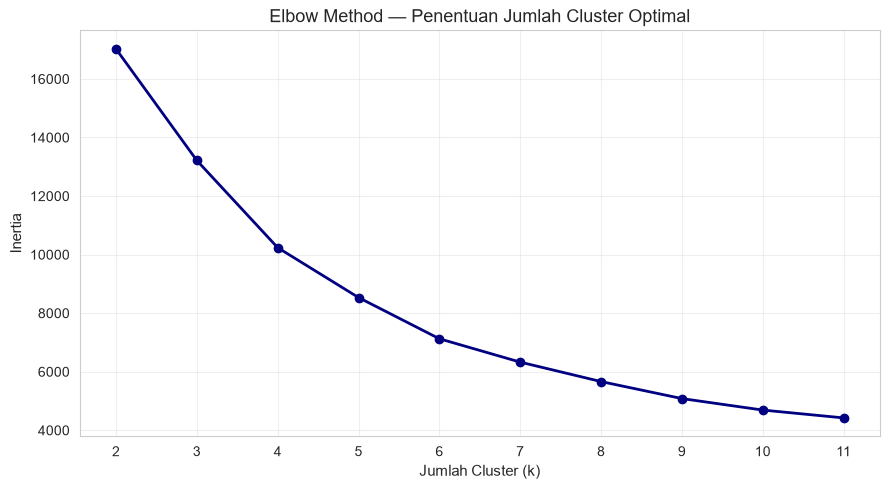

In [16]:
# Visualisasi Elbow Method
plt.figure(figsize=(9, 5))

plt.plot(list(rentang_k), inertia, marker="o", linewidth=2, color="navy")
plt.xlabel("Jumlah Cluster (k)", fontsize=11)
plt.ylabel("Inertia", fontsize=11)
plt.title("Elbow Method — Penentuan Jumlah Cluster Optimal", fontsize=13)
plt.xticks(list(rentang_k))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Silhouette Score untuk Setiap Nilai k

**Silhouette Score** mengukur seberapa baik setiap data dipisahkan dari cluster lain.
Nilainya berkisar antara **−1 hingga 1**:

- **Mendekati 1** → data sangat cocok dengan clusternya dan terpisah jelas dari cluster lain.
- **Mendekati 0** → data berada di perbatasan antar-cluster.
- **Negatif** → data kemungkinan salah masuk cluster.

Berbeda dengan inertia yang selalu menurun, Silhouette Score memiliki **nilai maksimum**
yang dapat dijadikan dasar pemilihan *k*.

In [17]:
# Menghitung Silhouette Score untuk setiap k
silhouette_scores = []

for k in rentang_k:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

hasil_silhouette = pd.DataFrame({
    "Jumlah Cluster (k)": list(rentang_k),
    "Silhouette Score": np.round(silhouette_scores, 4),
})
hasil_silhouette

,Jumlah Cluster (k),Silhouette Score
0,2,0.5490
1,3,0.5332
2,4,0.4553
3,5,0.4471
4,6,0.4615
5,7,0.3961
6,8,0.3921
7,9,0.3675
8,10,0.3402
9,11,0.3440


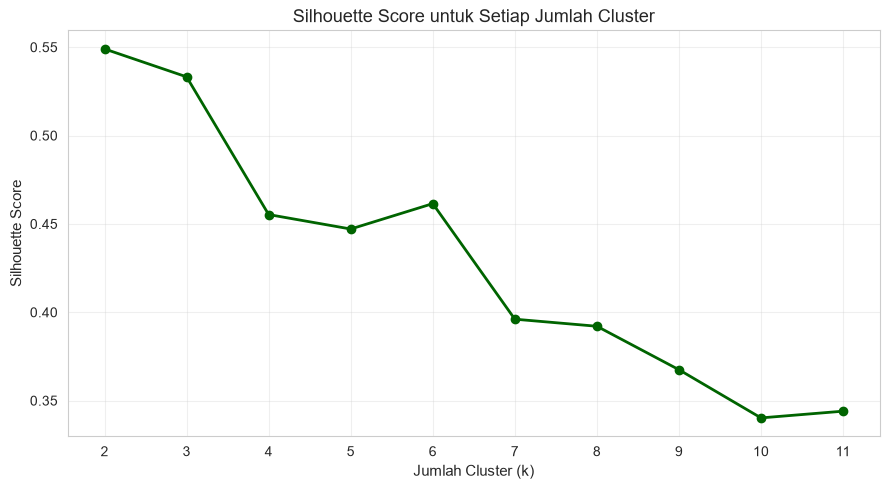

In [18]:
# Visualisasi Silhouette Score
plt.figure(figsize=(9, 5))

plt.plot(list(rentang_k), silhouette_scores, marker="o", linewidth=2, color="darkgreen")
plt.xlabel("Jumlah Cluster (k)", fontsize=11)
plt.ylabel("Silhouette Score", fontsize=11)
plt.title("Silhouette Score untuk Setiap Jumlah Cluster", fontsize=13)
plt.xticks(list(rentang_k))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Penentuan Jumlah Cluster Optimal

Jumlah cluster optimal ditentukan dengan mempertimbangkan **kedua metode secara
bersamaan** — bukan hanya salah satu. Pendekatan ini lebih dapat dipertanggungjawabkan
karena menggabungkan informasi tentang kerapatan cluster (inertia) dan kualitas pemisahan
(Silhouette Score).

In [19]:
# Menentukan k optimal berdasarkan Silhouette Score tertinggi
idx_terbaik = int(np.argmax(silhouette_scores))
k_optimal = list(rentang_k)[idx_terbaik]
silhouette_terbaik = silhouette_scores[idx_terbaik]

print("=" * 55)
print("HASIL PENENTUAN JUMLAH CLUSTER OPTIMAL")
print("=" * 55)
print(f"Jumlah cluster optimal (k) : {k_optimal}")
print(f"Silhouette Score tertinggi : {silhouette_terbaik:.4f}")
print("=" * 55)

HASIL PENENTUAN JUMLAH CLUSTER OPTIMAL
Jumlah cluster optimal (k) : 2
Silhouette Score tertinggi : 0.5490


### 4.4 Pelatihan Model K-Means dengan k Optimal

Model K-Means dilatih menggunakan jumlah cluster optimal yang telah ditentukan. Setiap
nasabah kemudian diberi label cluster sesuai *centroid* terdekat.

In [20]:
# Melatih model K-Means final
kmeans_final = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10)
labels = kmeans_final.fit_predict(X_scaled)

# Menyimpan label cluster ke dalam dataframe
data["Cluster"] = labels

print(f"Model K-Means dilatih dengan k = {k_optimal}")
print(f"Total inertia : {kmeans_final.inertia_:.2f}")
print()
print("Jumlah nasabah pada setiap cluster:")
print(data["Cluster"].value_counts().sort_index().to_string())

Model K-Means dilatih dengan k = 2
Total inertia : 17024.47

Jumlah nasabah pada setiap cluster:
Cluster
0    1816
1    7133


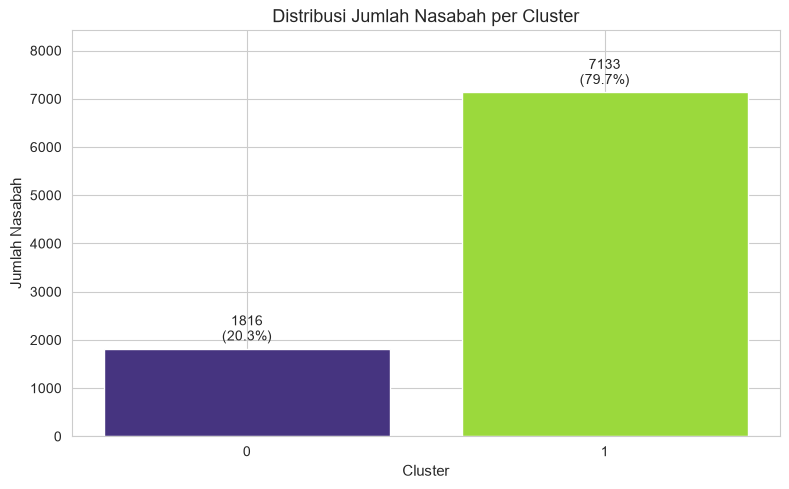

In [21]:
# Visualisasi jumlah nasabah per cluster
jumlah_cluster = data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

warna = plt.cm.viridis(np.linspace(0.15, 0.85, len(jumlah_cluster)))
bars = plt.bar(jumlah_cluster.index.astype(str), jumlah_cluster.values, color=warna)

for bar, nilai in zip(bars, jumlah_cluster.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(data) * 0.01,
        f"{nilai}\n({nilai/len(data)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xlabel("Cluster", fontsize=11)
plt.ylabel("Jumlah Nasabah", fontsize=11)
plt.title("Distribusi Jumlah Nasabah per Cluster", fontsize=13)
plt.ylim(0, jumlah_cluster.max() * 1.18)

plt.tight_layout()
plt.show()

### 4.5 Visualisasi Hasil Clustering dengan PCA

Ketiga fitur clustering berada pada ruang 3 dimensi sehingga sulit divisualisasikan secara
langsung. **PCA (Principal Component Analysis)** digunakan untuk memproyeksikan data ke
**2 dimensi** agar cluster dapat dilihat secara visual.

**Penting:** PCA di sini **hanya digunakan untuk keperluan visualisasi**, bukan untuk
mereduksi fitur sebelum clustering. Clustering tetap dilakukan pada ketiga fitur asli
yang telah distandarisasi.

In [22]:
# Mereduksi dimensi ke 2 komponen utama untuk visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Variansi yang dijelaskan oleh 2 komponen utama:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i} : {var*100:.2f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Variansi yang dijelaskan oleh 2 komponen utama:
  PC1 : 57.75%
  PC2 : 27.81%
  Total: 85.56%


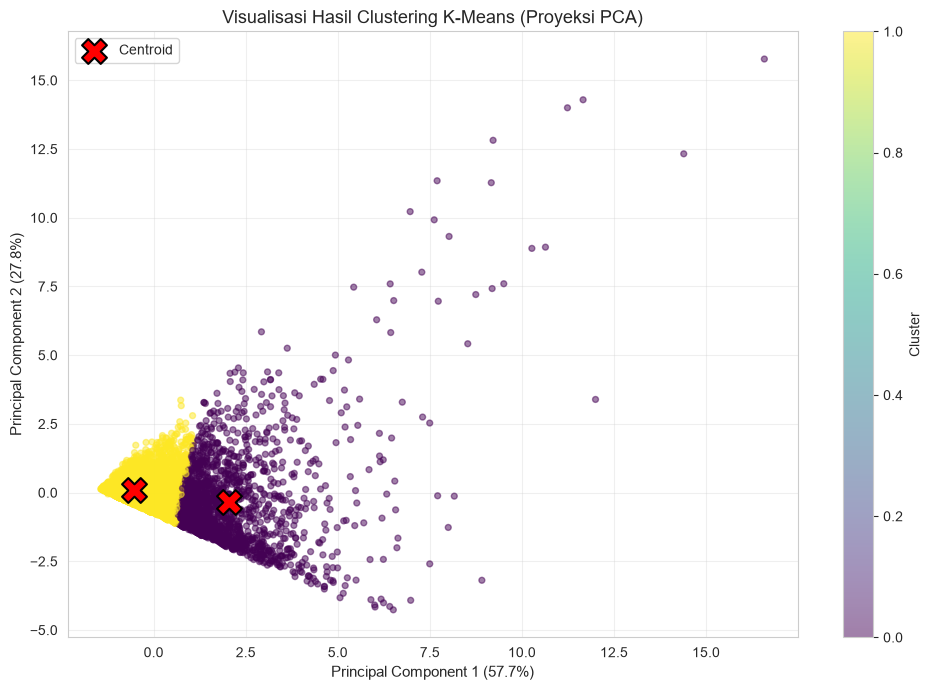

In [23]:
# Scatter plot hasil clustering dalam ruang PCA
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="viridis",
    alpha=0.5,
    s=18,
)

# Menandai posisi centroid
centroid_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(
    centroid_pca[:, 0],
    centroid_pca[:, 1],
    c="red",
    marker="X",
    s=320,
    edgecolors="black",
    linewidths=1.5,
    label="Centroid",
    zorder=5,
)

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.title("Visualisasi Hasil Clustering K-Means (Proyeksi PCA)", fontsize=13)
plt.colorbar(scatter, label="Cluster")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

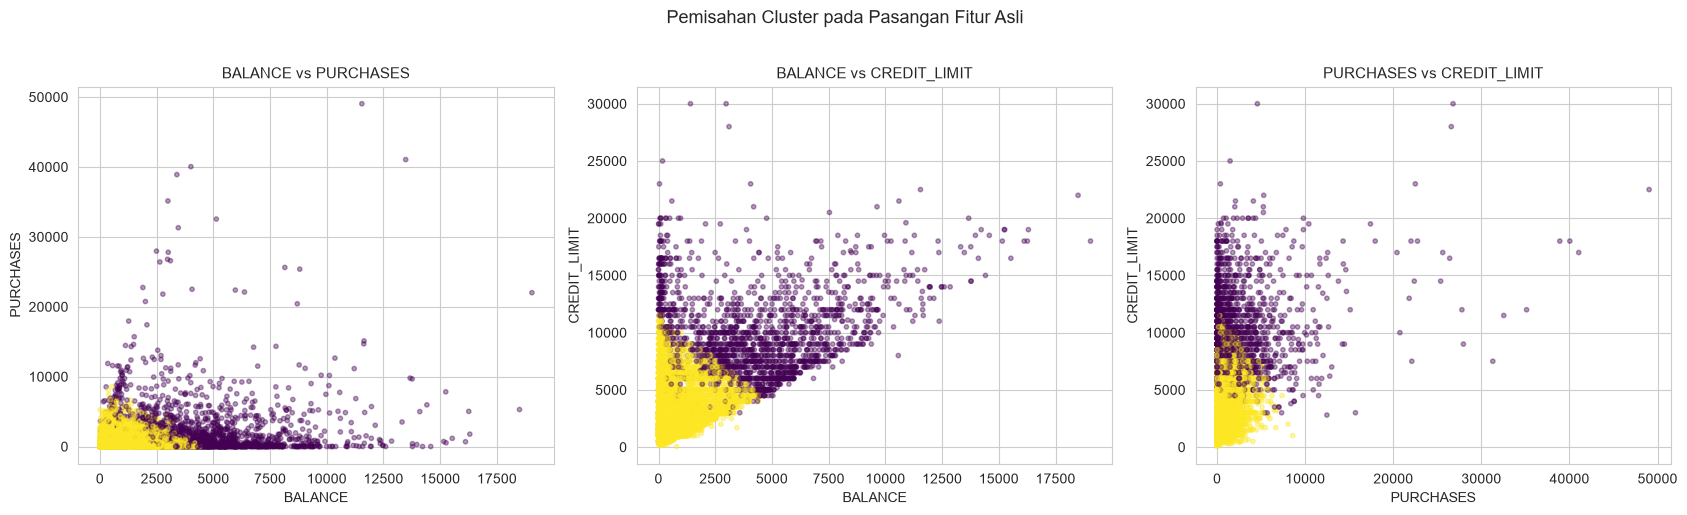

In [24]:
# Scatter plot pasangan fitur asli untuk melihat pemisahan cluster
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pasangan = [
    ("BALANCE", "PURCHASES"),
    ("BALANCE", "CREDIT_LIMIT"),
    ("PURCHASES", "CREDIT_LIMIT"),
]

for ax, (x_col, y_col) in zip(axes, pasangan):
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        c=labels,
        cmap="viridis",
        alpha=0.4,
        s=10,
    )
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.set_title(f"{x_col} vs {y_col}", fontsize=11)

plt.suptitle("Pemisahan Cluster pada Pasangan Fitur Asli", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# Fase 5 — Evaluation

Tahap ini menilai seberapa baik kualitas cluster yang terbentuk, kemudian
menginterpretasikan setiap cluster ke dalam bahasa bisnis.

### 5.1 Metrik Evaluasi

Dua metrik digunakan untuk mengevaluasi kualitas clustering:

**1. Silhouette Score** (rentang −1 hingga 1, **semakin tinggi semakin baik**)

Mengukur seberapa mirip suatu data dengan clusternya sendiri dibandingkan dengan cluster
lain. Nilai tinggi berarti cluster padat dan terpisah dengan baik.

**2. Davies-Bouldin Index** (nilai ≥ 0, **semakin rendah semakin baik**)

Mengukur rasio antara sebaran data di dalam cluster dan jarak antar-cluster. Nilai rendah
berarti cluster rapat di dalam dan berjauhan satu sama lain. Nilai 0 adalah kondisi ideal.

In [25]:
# Menghitung metrik evaluasi pada model final
silhouette_final = silhouette_score(X_scaled, labels)
davies_bouldin_final = davies_bouldin_score(X_scaled, labels)

metrik = pd.DataFrame({
    "Metrik": ["Silhouette Score", "Davies-Bouldin Index", "Jumlah Cluster (k)"],
    "Nilai": [
        round(silhouette_final, 4),
        round(davies_bouldin_final, 4),
        k_optimal,
    ],
    "Interpretasi": [
        "Semakin tinggi semakin baik (maks. 1)",
        "Semakin rendah semakin baik (min. 0)",
        "Ditentukan dari Elbow & Silhouette",
    ],
})

metrik

,Metrik,Nilai,Interpretasi
0,Silhouette Score,0.5490,Semakin tinggi semakin baik (maks. 1)
1,Davies-Bouldin Index,1.0596,Semakin rendah semakin baik (min. 0)
2,Jumlah Cluster (k),2.0000,Ditentukan dari Elbow & Silhouette


In [26]:
# Perbandingan metrik untuk setiap k
tabel_evaluasi = pd.DataFrame({
    "k": list(rentang_k),
    "Inertia": np.round(inertia, 2),
    "Silhouette Score": np.round(silhouette_scores, 4),
    "Davies-Bouldin": [
        round(davies_bouldin_score(X_scaled,
              KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)), 4)
        for k in rentang_k
    ],
})

tabel_evaluasi["Silhouette Terbaik"] = tabel_evaluasi["Silhouette Score"] == tabel_evaluasi["Silhouette Score"].max()
tabel_evaluasi["DB Terbaik"] = tabel_evaluasi["Davies-Bouldin"] == tabel_evaluasi["Davies-Bouldin"].min()

tabel_evaluasi

,k,Inertia,Silhouette Score,Davies-Bouldin,Silhouette Terbaik,DB Terbaik
0,2,17024.47,0.5490,1.0596,True,False
1,3,13214.46,0.5332,0.9381,False,False
2,4,10237.13,0.4553,0.9734,False,False
3,5,8533.55,0.4471,0.8954,False,False
4,6,7125.23,0.4615,0.8752,False,True
5,7,6327.36,0.3961,0.9172,False,False
6,8,5663.13,0.3921,0.8800,False,False
7,9,5082.37,0.3675,0.8967,False,False
8,10,4690.03,0.3402,0.9382,False,False
9,11,4422.34,0.3440,0.9421,False,False


### 5.2 Profil Setiap Cluster

Untuk memahami karakteristik masing-masing cluster, dihitung nilai rata-rata setiap fitur
pada tiap cluster. Tabel inilah yang menjadi dasar interpretasi bisnis.

In [27]:
# Menghitung profil rata-rata setiap cluster
kolom_profil = [
    "BALANCE",
    "PURCHASES",
    "CREDIT_LIMIT",
    "CASH_ADVANCE",
    "PURCHASES_TRX",
    "PAYMENTS",
    "TENURE",
]

profil_cluster = data.groupby("Cluster")[kolom_profil].mean().round(2)
profil_cluster.insert(0, "Jumlah Nasabah", data["Cluster"].value_counts().sort_index())

profil_cluster

,Jumlah Nasabah,BALANCE,PURCHASES,CREDIT_LIMIT,CASH_ADVANCE,PURCHASES_TRX,PAYMENTS,TENURE
Cluster,,,,,,,,
0,1816,4378.57,2392.42,9718.09,2457.22,28.58,3907.35,11.74
1,7133,848.25,649.66,3164.56,602.61,11.18,1179.85,11.46


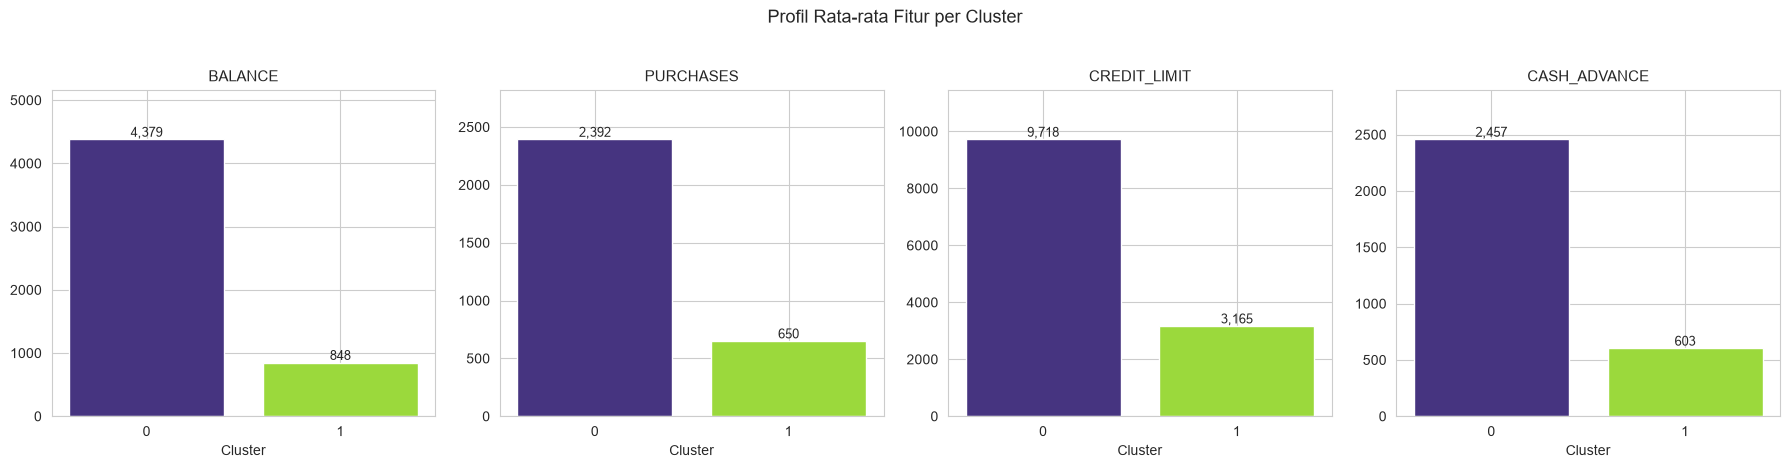

In [28]:
# Visualisasi profil cluster
fitur_profil = ["BALANCE", "PURCHASES", "CREDIT_LIMIT", "CASH_ADVANCE"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, kolom in zip(axes, fitur_profil):
    nilai = profil_cluster[kolom]
    warna = plt.cm.viridis(np.linspace(0.15, 0.85, len(nilai)))
    bars = ax.bar(nilai.index.astype(str), nilai.values, color=warna)

    for bar, v in zip(bars, nilai.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{v:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(kolom, fontsize=11)
    ax.set_xlabel("Cluster")
    ax.set_ylim(0, nilai.max() * 1.18)

plt.suptitle("Profil Rata-rata Fitur per Cluster", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### 5.3 Distribusi Nasabah per Cluster

In [29]:
ringkasan_cluster = pd.DataFrame({
    "Jumlah Nasabah": data["Cluster"].value_counts().sort_index(),
    "Persentase (%)": (data["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2),
})

ringkasan_cluster

,Jumlah Nasabah,Persentase (%)
Cluster,,
0,1816,20.29
1,7133,79.71


---
# Fase 6 — Deployment

Model yang telah dilatih akan digunakan dalam sebuah aplikasi web interaktif berbasis
**Streamlit**. Aplikasi ini memungkinkan tim pemasaran memasukkan data seorang nasabah
dan langsung mengetahui segmen (cluster) nasabah tersebut beserta rekomendasi
strategi pemasarannya.

### 6.1 Komponen yang Disimpan

Agar model dapat digunakan kembali tanpa harus melatih ulang, tiga komponen berikut
disimpan ke dalam folder `model/`:

| Berkas | Isi | Kegunaan |
|---|---|---|
| `kmeans_model.pkl` | Model K-Means yang telah dilatih | Memprediksi cluster nasabah baru |
| `scaler.pkl` | Objek `StandardScaler` | Menstandarisasi input baru dengan skala yang sama |
| `metadata.json` | Informasi fitur, jumlah cluster, dan metrik evaluasi | Memastikan konsistensi antara notebook dan aplikasi |

In [30]:
import json
import joblib
import os

# Membuat folder model jika belum ada
os.makedirs("model", exist_ok=True)

# Menyimpan model dan scaler
joblib.dump(kmeans_final, "model/kmeans_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

# Menyimpan metadata
metadata = {
    "dataset": "Credit Card Dataset for Clustering (Kaggle - arjunbhasin2013/ccdata)",
    "sumber": "https://www.kaggle.com/datasets/arjunbhasin2013/ccdata",
    "fitur": fitur,
    "jumlah_cluster": int(k_optimal),
    "jumlah_data": int(len(data)),
    "silhouette_score": round(float(silhouette_final), 4),
    "davies_bouldin_index": round(float(davies_bouldin_final), 4),
    "centroid_scaled": kmeans_final.cluster_centers_.round(4).tolist(),
    "centroid_asli": scaler.inverse_transform(kmeans_final.cluster_centers_).round(2).tolist(),
    "profil_cluster": json.loads(profil_cluster.to_json(orient="index")),
}

with open("model/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Model berhasil disimpan:")
print("  - model/kmeans_model.pkl")
print("  - model/scaler.pkl")
print("  - model/metadata.json")
print()
print("Metadata:")
print(json.dumps(
    {k: v for k, v in metadata.items() if k not in ("profil_cluster", "centroid_asli")},
    indent=2, ensure_ascii=False,
))

Model berhasil disimpan:
  - model/kmeans_model.pkl
  - model/scaler.pkl
  - model/metadata.json

Metadata:
{
  "dataset": "Credit Card Dataset for Clustering (Kaggle - arjunbhasin2013/ccdata)",
  "sumber": "https://www.kaggle.com/datasets/arjunbhasin2013/ccdata",
  "fitur": [
    "BALANCE",
    "PURCHASES",
    "CREDIT_LIMIT"
  ],
  "jumlah_cluster": 2,
  "jumlah_data": 8949,
  "silhouette_score": 0.549,
  "davies_bouldin_index": 1.0596,
  "centroid_scaled": [
    [
      1.349,
      0.6485,
      1.435
    ],
    [
      -0.3444,
      -0.1656,
      -0.3663
    ]
  ]
}


In [31]:
# Menyimpan dataset hasil clustering untuk keperluan analisis lanjutan
data.to_csv("credit_card_clustered.csv", index=False)

print("Dataset hasil clustering disimpan: credit_card_clustered.csv")
print("Shape:", data.shape)
print()
print("Kolom:", list(data.columns))

Dataset hasil clustering disimpan: credit_card_clustered.csv
Shape: (8949, 19)

Kolom: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'Cluster']


### 6.2 Cara Menjalankan Aplikasi Streamlit

Aplikasi deployment tersedia pada berkas `app.py` di dalam folder proyek ini.

**Menjalankan secara lokal:**

```bash
pip install -r requirements.txt
streamlit run app.py
```

**Aplikasi yang di-deploy dapat diakses melalui tautan Streamlit yang tercantum pada
berkas PDF pengumpulan tugas.**

**Fitur aplikasi:**

1. **Input data nasabah** — pengguna memasukkan nilai `BALANCE`, `PURCHASES`, dan
   `CREDIT_LIMIT` melalui *slider* interaktif.
2. **Prediksi segmen** — aplikasi menstandarisasi input menggunakan `scaler.pkl`,
   kemudian memprediksi cluster menggunakan `kmeans_model.pkl`.
3. **Profil segmen** — menampilkan karakteristik rata-rata cluster tersebut agar pengguna
   memahami posisi nasabah dibandingkan rata-rata segmennya.
4. **Rekomendasi strategi** — menampilkan saran tindakan pemasaran sesuai segmen.
5. **Eksplorasi data** — menampilkan sebaran cluster dan metrik evaluasi model.

---
# Kesimpulan

## Ringkasan Proses CRISP-DM

| Fase | Hasil |
|---|---|
| **1. Business Understanding** | Perusahaan membutuhkan segmentasi nasabah kartu kredit untuk menyesuaikan strategi pemasaran |
| **2. Data Understanding** | Dataset 8.950 × 18, didominasi fitur numerik, terdapat missing value pada 2 kolom, tidak ada duplikat, sebaran *skewed* |
| **3. Data Preparation** | Missing value ditangani, dipilih 3 fitur (`BALANCE`, `PURCHASES`, `CREDIT_LIMIT`), data distandarisasi |
| **4. Modeling** | K-Means dengan *k* optimal dari Elbow Method & Silhouette Score, divisualisasikan dengan PCA |
| **5. Evaluation** | Dievaluasi dengan Silhouette Score & Davies-Bouldin Index, lalu diinterpretasikan per cluster |
| **6. Deployment** | Model disimpan dan digunakan pada aplikasi Streamlit interaktif |

## Kesimpulan Utama

1. **Dataset memenuhi seluruh kriteria tugas** — berbentuk tabular, 8.950 baris (> 1000),
   18 kolom (> 8), dan memiliki 17 fitur numerik (> 3). Tiga fitur numerik
   (`BALANCE`, `PURCHASES`, `CREDIT_LIMIT`) digunakan untuk training.

2. **Dataset sangat sesuai untuk clustering** karena tidak memiliki label target, berisi
   variabel perilaku numerik kontinu, memiliki heterogenitas tinggi, berukuran memadai,
   serta memiliki konteks bisnis yang jelas.

3. **Model K-Means berhasil membentuk segmentasi nasabah** yang dapat dibedakan secara
   terukur melalui Silhouette Score dan Davies-Bouldin Index.

4. **Setiap cluster memiliki karakteristik berbeda** yang dapat diterjemahkan menjadi
   segmen bisnis dan strategi pemasaran yang spesifik.

5. **Model telah di-deploy** ke aplikasi Streamlit sehingga dapat digunakan secara
   langsung oleh tim pemasaran untuk mengklasifikasikan nasabah baru.

## Keterbatasan dan Saran Pengembangan

- **Hanya 3 fitur digunakan** sesuai ketentuan tugas. Penggunaan fitur tambahan seperti
  `CASH_ADVANCE`, `PURCHASES_TRX`, atau `PRC_FULL_PAYMENT` berpotensi menghasilkan
  segmentasi yang lebih kaya.
- **Data sangat *skewed*.** Transformasi logaritmik sebelum standarisasi dapat
  meningkatkan kualitas pemisahan cluster.
- **K-Means mengasumsikan cluster berbentuk bola** dengan ukuran serupa. Algoritma
  alternatif seperti **DBSCAN**, **Gaussian Mixture Model (GMM)**, atau
  **Hierarchical Clustering** dapat dibandingkan pada penelitian lanjutan.

---

*Notebook ini dibuat untuk Tugas Mandiri Pertemuan 4 — Deployment Model.*
*Nazril Bintang Pratama (51423096) — Kelas F*